# Mycobacterium tuberculosis Comparative Genomics

## Genome Statistics and Analysis

In [1]:
# Import libraries and setup
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set up paths
project_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
sys.path.append(str(project_root / "Scripts"))

In [3]:
# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(f"Project Root: {project_root}")

Project Root: C:\Users\dalto\Desktop\Education Resources\Personal\Projects\Mycobacterium_tuberculosis_Comparative_Genomics


In [4]:
# Define GC calculation
def calculate_gc(seq):
    """Calculate GC content percentage for a sequence (workaround for Bio.SeqUtils.GC)."""
    if len(seq) == 0:
        return 0
    gc_count = seq.count('G') + seq.count('C') + seq.count('g') + seq.count('c')
    return (gc_count / len(seq)) * 100

In [5]:
# Define GC Skew
def calculate_gc_skew(seq, window=100):
    """Calculate GC skew (G-C)/(G+C) for a sequence."""
    if len(seq) < window:
        return 0
    g_count = seq.count('G') + seq.count('g')
    c_count = seq.count('C') + seq.count('c')
    if (g_count + c_count) == 0:
        return 0
    return (g_count - c_count) / (g_count + c_count)

In [6]:
# Define AT Skew
def calculate_at_skew(seq, window=100):
    """Calculate AT skew (A-T)/(A+T) for a sequence."""
    if len(seq) < window:
        return 0
    a_count = seq.count('A') + seq.count('a')
    t_count = seq.count('T') + seq.count('t')
    if (a_count + t_count) == 0:
        return 0
    return (a_count - t_count) / (a_count + t_count)

In [7]:
# Define GenomeAnalyzer module
class GenomeAnalyzer:
    """Workaround class to analyze genome data."""
    
    def __init__(self, project_root):
        self.project_root = project_root
        self.data_dir = project_root / "Data" / "Raw"
    
    def load_genome(self, strain):
        """Load genome from FASTA file."""
        fasta_path = self.data_dir / f"{strain}_fasta.fna"
        
        if not fasta_path.exists():
            raise FileNotFoundError(f"FASTA file not found for {strain}")
        
        records = list(SeqIO.parse(fasta_path, "fasta"))
        return records
    
    def calculate_basic_stats(self, records):
        """Calculate basic statistics for genome records."""
        if not records:
            return {}
        
        # Get contig lengths
        contig_lengths = sorted([len(rec.seq) for rec in records], reverse=True)
        total_length = sum(contig_lengths)
        
        # Calculate GC content using workaround
        gc_total = 0
        for rec in records:
            gc_total += calculate_gc(rec.seq) * len(rec.seq)
        gc_content = (gc_total / total_length) if total_length > 0 else 0
        
        # Calculate N50, N75, L50
        n50 = self._calculate_nx(contig_lengths, total_length, 50)
        n75 = self._calculate_nx(contig_lengths, total_length, 75)
        l50 = self._calculate_lx(contig_lengths, total_length, 50)
        
        # Calculate average length
        avg_length = total_length / len(contig_lengths) if contig_lengths else 0
        
        return {
            'total_length': total_length,
            'gc_content': gc_content,
            'num_contigs': len(contig_lengths),
            'n50': n50,
            'n75': n75,
            'l50': l50,
            'average_length': avg_length,
            'min_contig_length': min(contig_lengths) if contig_lengths else 0,
            'max_contig_length': max(contig_lengths) if contig_lengths else 0,
            'contig_lengths': contig_lengths
        }
    
    def calculate_sliding_window_stats(self, sequence, window_size=5000, step_size=1000):
        """Calculate sliding window statistics for a sequence."""
        from Bio.Seq import Seq
        import pandas as pd
        
        positions = []
        gc_contents = []
        gc_skews = []
        at_skews = []
        
        seq_length = len(sequence)
        
        for start in range(0, seq_length - window_size + 1, step_size):
            end = start + window_size
            window_seq = sequence[start:end]
            
            # Calculate statistics for this window
            gc_content = calculate_gc(window_seq)
            gc_skew_val = calculate_gc_skew(window_seq)
            at_skew_val = calculate_at_skew(window_seq)
            
            positions.append(start + window_size // 2)
            gc_contents.append(gc_content)
            gc_skews.append(gc_skew_val)
            at_skews.append(at_skew_val)
        
        # Create DataFrame
        window_stats = pd.DataFrame({
            'position': positions,
            'gc_content': gc_contents,
            'gc_skew': gc_skews,
            'at_skew': at_skews
        })
        
        return window_stats
    
    def _calculate_nx(self, lengths, total, x):
        """Calculate N50, N75, etc."""
        if not lengths:
            return 0
        
        target_length = total * (x / 100)
        cumulative = 0
        
        for length in lengths:
            cumulative += length
            if cumulative >= target_length:
                return length
        
        return lengths[-1]
    
    def _calculate_lx(self, lengths, total, x):
        """Calculate L50, L75, etc."""
        if not lengths:
            return 0
        
        target_length = total * (x / 100)
        cumulative = 0
        count = 0
        
        for length in lengths:
            cumulative += length
            count += 1
            if cumulative >= target_length:
                return count
        
        return len(lengths)

In [8]:
# Initialize analyzer and load data
analyzer = GenomeAnalyzer(project_root)
raw_dir = project_root / "Data" / "Raw"
results_dir = project_root / "Results"

In [9]:
# Check for existing results
print("Checking for existing analysis results...")
if (results_dir / "genome_comparison_stats.csv").exists():
    print("✓ Found existing analysis results")
    comparison_df = pd.read_csv(results_dir / "genome_comparison_stats.csv")
    display(comparison_df)
else:
    print("✗ No existing results found. Running analysis...")

Checking for existing analysis results...
✗ No existing results found. Running analysis...


In [10]:
# Analyze genomes
print("Analyzing genomes...")

Analyzing genomes...


In [11]:
# Load Genomes
h37rv_records = analyzer.load_genome("H37Rv")
cdc1551_records = analyzer.load_genome("CDC1551")

In [12]:
# Calculate Statistics
h37rv_stats = analyzer.calculate_basic_stats(h37rv_records)
cdc1551_stats = analyzer.calculate_basic_stats(cdc1551_records)

In [13]:
# Create comparison DataFrame
comparison_data = []
for strain, stats in [("H37Rv", h37rv_stats), ("CDC1551", cdc1551_stats)]:
    comparison_data.append({
        'Strain': strain,
        'Contigs': stats['num_contigs'],
        'Total_Length_bp': stats['total_length'],
        'GC_Content_%': round(stats['gc_content'], 2),
        'Average_Contig_bp': int(stats['average_length']),
        'N50_bp': stats['n50'],
        'N75_bp': stats['n75'],
        'L50': stats['l50']
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Strain,Contigs,Total_Length_bp,GC_Content_%,Average_Contig_bp,N50_bp,N75_bp,L50
0,H37Rv,1,4411532,65.61,4411532,4411532,4411532,1
1,CDC1551,1,4403837,65.61,4403837,4403837,4403837,1


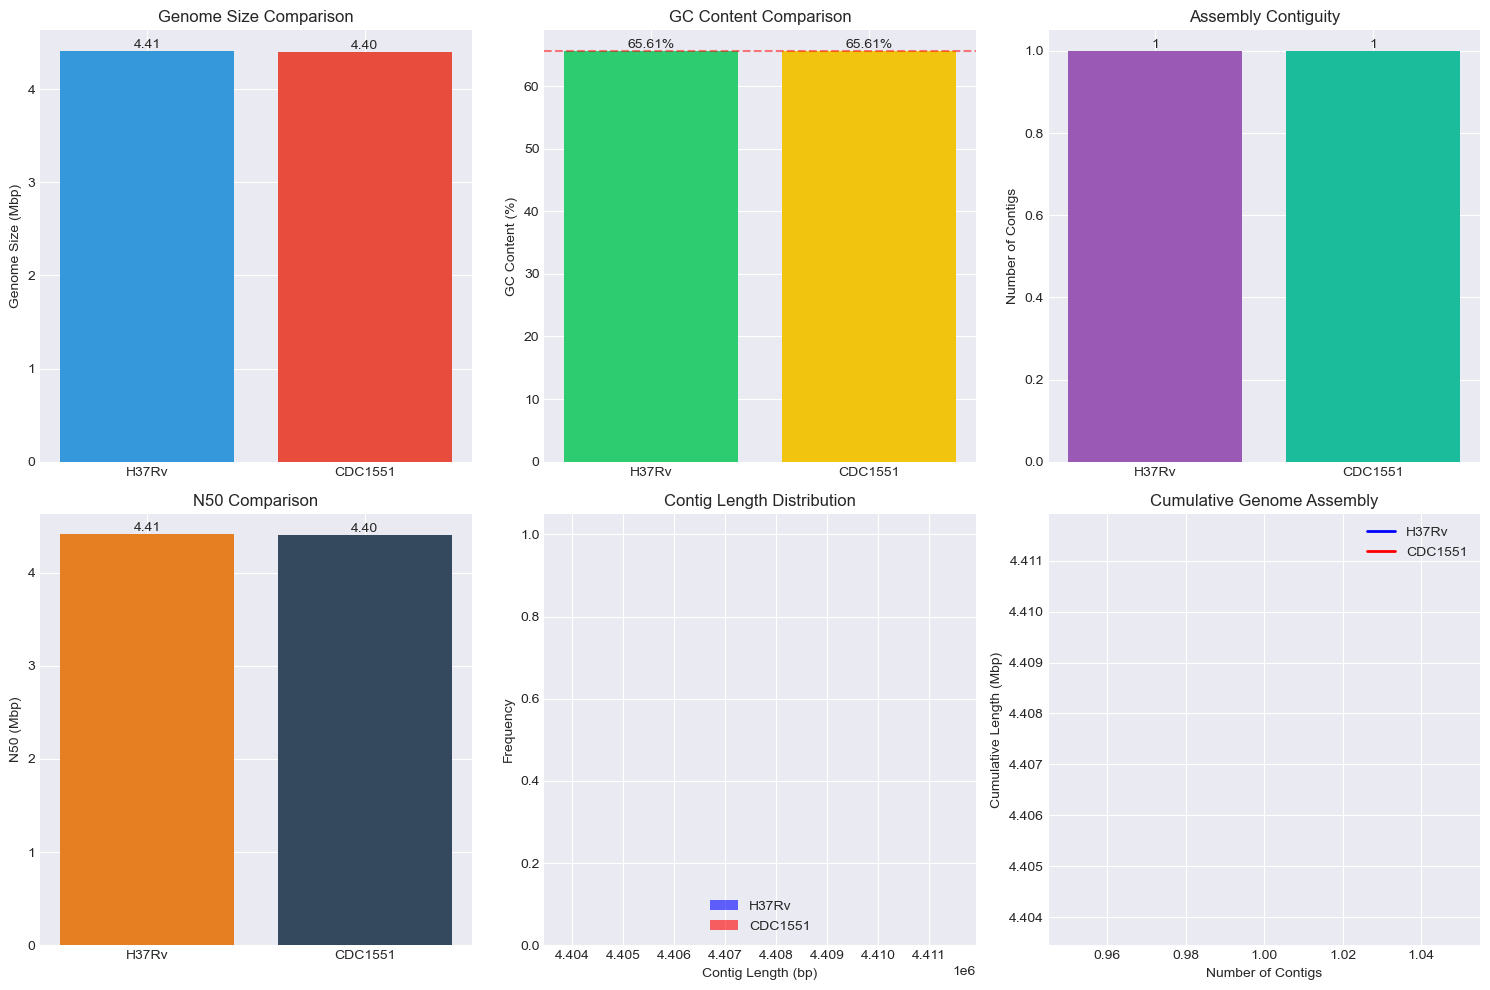

✓ Visualization saved to Results/Plots/basic_genome_comparison.png


In [14]:
# Visualization - Basic Statistics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Genome size
axes[0,0].bar(comparison_df['Strain'], comparison_df['Total_Length_bp'] / 1e6, 
              color=['#3498db', '#e74c3c'])
axes[0,0].set_ylabel('Genome Size (Mbp)')
axes[0,0].set_title('Genome Size Comparison')
for i, v in enumerate(comparison_df['Total_Length_bp'] / 1e6):
    axes[0,0].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# Plot 2: GC Content
axes[0,1].bar(comparison_df['Strain'], comparison_df['GC_Content_%'],
            color=['#2ecc71', '#f1c40f'])
axes[0,1].set_ylabel('GC Content (%)')
axes[0,1].set_title('GC Content Comparison')
axes[0,1].axhline(y=65.6, color='r', linestyle='--', alpha=0.5, label='Mtb avg')
for i, v in enumerate(comparison_df['GC_Content_%']):
    axes[0,1].text(i, v, f'{v:.2f}%', ha='center', va='bottom')

# Plot 3: Contig Count
axes[0,2].bar(comparison_df['Strain'], comparison_df['Contigs'],
              color=['#9b59b6', '#1abc9c'])
axes[0,2].set_ylabel('Number of Contigs')
axes[0,2].set_title('Assembly Contiguity')
for i, v in enumerate(comparison_df['Contigs']):
    axes[0,2].text(i, v, str(v), ha='center', va='bottom')

# Plot 4: N50
axes[1,0].bar(comparison_df['Strain'], comparison_df['N50_bp'] / 1e6,
              color=['#e67e22', '#34495e'])
axes[1,0].set_ylabel('N50 (Mbp)')
axes[1,0].set_title('N50 Comparison')
for i, v in enumerate(comparison_df['N50_bp'] / 1e6):
    axes[1,0].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# Plot 5: Contig Length Distribution
for i, (strain, color) in enumerate([('H37Rv', 'blue'), ('CDC1551', 'red')]):
    stats = h37rv_stats if strain == 'H37Rv' else cdc1551_stats
    axes[1,1].hist(stats['contig_lengths'], bins=20, alpha=0.6, color=color, label=strain)
axes[1,1].set_xlabel('Contig Length (bp)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Contig Length Distribution')
axes[1,1].legend()

# Plot 6: Cumulative Genome Length
for i, (strain, color) in enumerate([('H37Rv', 'blue'), ('CDC1551', 'red')]):
    stats = h37rv_stats if strain == 'H37Rv' else cdc1551_stats
    sorted_lengths = sorted(stats['contig_lengths'], reverse=True)
    cumulative = np.cumsum(sorted_lengths)
    axes[1,2].plot(range(1, len(cumulative) + 1), cumulative / 1e6, color=color, label=strain, linewidth=2)
axes[1,2].set_xlabel('Number of Contigs')
axes[1,2].set_ylabel('Cumulative Length (Mbp)')
axes[1,2].set_title('Cumulative Genome Assembly')
axes[1,2].legend()

plt.tight_layout()
plt.savefig(results_dir / 'Plots' / 'basic_genome_comparison.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to Results/Plots/basic_genome_comparison.png")

In [15]:
# GC Content Analysis
print("Performing GC content analysis...")

# Get the main chromosome (largest contig) for each
h37rv_main = max(h37rv_records, key=lambda x: len(x.seq))
cdc1551_main = max(cdc1551_records, key=lambda x: len(x.seq))

print(f"Main chromosome sizes:")
print(f"  H37Rv: {len(h37rv_main.seq):,} bp")
print(f"  CDC1551: {len(cdc1551_main.seq):,} bp")

# Calculate sliding window statistics
window_size = 5000
h37rv_windows = analyzer.calculate_sliding_window_stats(str(h37rv_main.seq), window_size)
cdc1551_windows = analyzer.calculate_sliding_window_stats(str(cdc1551_main.seq), window_size)

print(f"\nSliding window analysis complete ({window_size:,} bp windows):")
print(f"  H37Rv: {len(h37rv_windows)} windows")
print(f"  CDC1551: {len(cdc1551_windows)} windows")

Performing GC content analysis...
Main chromosome sizes:
  H37Rv: 4,411,532 bp
  CDC1551: 4,403,837 bp

Sliding window analysis complete (5,000 bp windows):
  H37Rv: 4407 windows
  CDC1551: 4399 windows


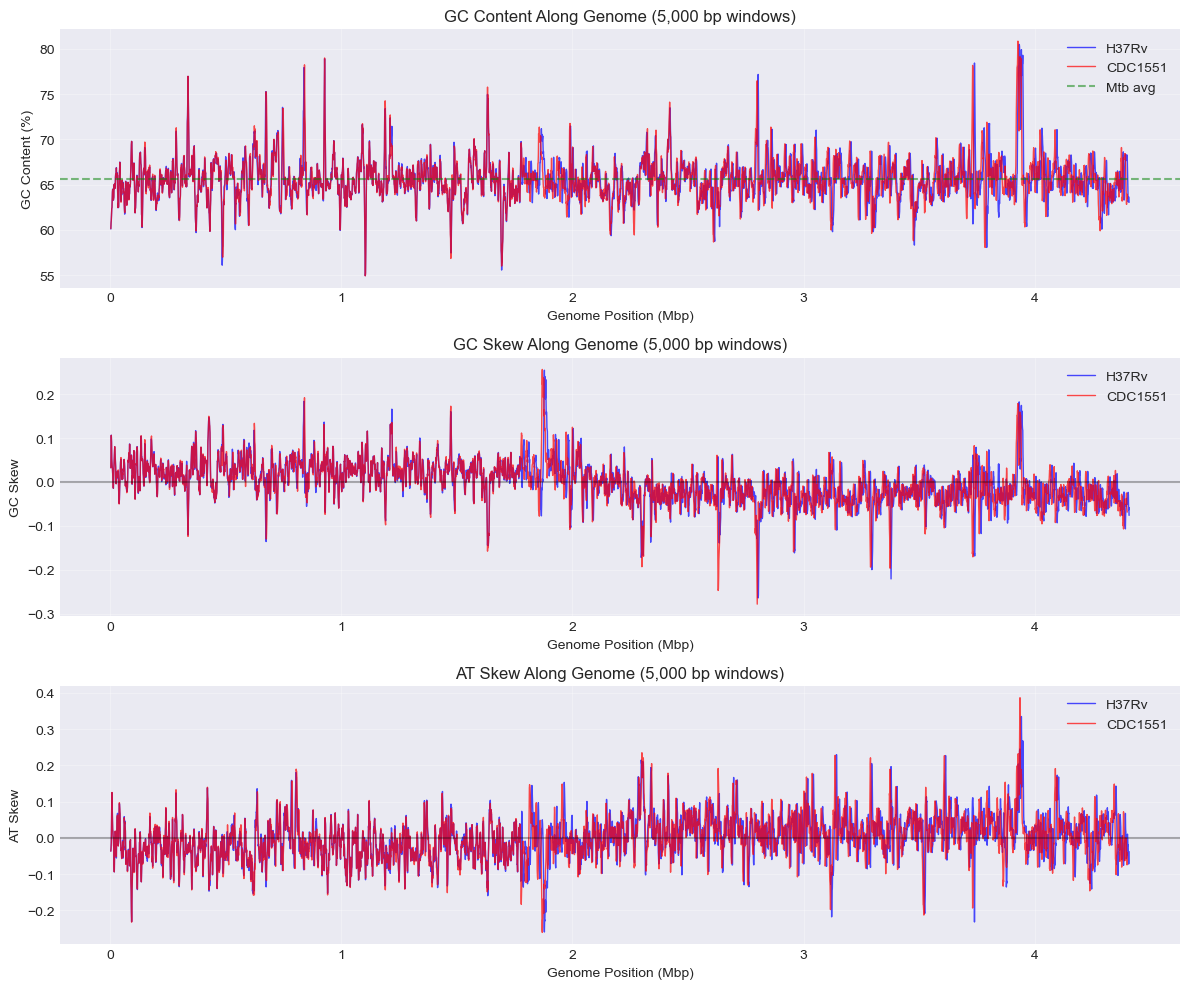

✓ GC profile visualization saved to Results/Plots/gc_profiles.png


In [16]:
# Visualize GC Profiles
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot GC Content along genome
axes[0].plot(h37rv_windows['position'] / 1e6, h37rv_windows['gc_content'], 
             'b-', alpha=0.7, label='H37Rv', linewidth=1)
axes[0].plot(cdc1551_windows['position'] / 1e6, cdc1551_windows['gc_content'], 
             'r-', alpha=0.7, label='CDC1551', linewidth=1)
axes[0].axhline(y=65.6, color='green', linestyle='--', alpha=0.5, label='Mtb avg')
axes[0].set_xlabel('Genome Position (Mbp)')
axes[0].set_ylabel('GC Content (%)')
axes[0].set_title(f'GC Content Along Genome ({window_size:,} bp windows)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot GC Skew
axes[1].plot(h37rv_windows['position'] / 1e6, h37rv_windows['gc_skew'], 
             'b-', alpha=0.7, label='H37Rv', linewidth=1)
axes[1].plot(cdc1551_windows['position'] / 1e6, cdc1551_windows['gc_skew'], 
             'r-', alpha=0.7, label='CDC1551', linewidth=1)
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Genome Position (Mbp)')
axes[1].set_ylabel('GC Skew')
axes[1].set_title(f'GC Skew Along Genome ({window_size:,} bp windows)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot AT Skew
axes[2].plot(h37rv_windows['position'] / 1e6, h37rv_windows['at_skew'], 
             'b-', alpha=0.7, label='H37Rv', linewidth=1)
axes[2].plot(cdc1551_windows['position'] / 1e6, cdc1551_windows['at_skew'], 
             'r-', alpha=0.7, label='CDC1551', linewidth=1)
axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[2].set_xlabel('Genome Position (Mbp)')
axes[2].set_ylabel('AT Skew')
axes[2].set_title(f'AT Skew Along Genome ({window_size:,} bp windows)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'Plots' / 'gc_profiles.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ GC profile visualization saved to Results/Plots/gc_profiles.png")

In [17]:
# Save Results
print("Saving analysis results...")

#Save Comparison Data
(results_dir / "Plots").mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(results_dir / "genome_comparison_stats.csv", index=False)

# Save Sliding Window Data
h37rv_windows.to_csv(results_dir / "h37rv_sliding_window.csv", index=False)
cdc1551_windows.to_csv(results_dir / "cdc1551_sliding_window.csv", index=False)

# Save Contig Details
contig_data = []
for rec in h37rv_records:
    contig_data.append({
        'Strain': 'H37Rv',
        'Contig_ID': rec.id,
        'Length': len(rec.seq),
        'GC_Content': calculate_gc(str(rec.seq)),
        'Description': rec.description[:100]
    })

for rec in cdc1551_records:
    contig_data.append({
        'Strain': 'CDC1551',
        'Contig_ID': rec.id,
        'Length': len(rec.seq),
        'GC_Content': calculate_gc(str(rec.seq)),
        'Description': rec.description[:100]
    })

contig_df = pd.DataFrame(contig_data)
contig_df.to_csv(results_dir / "contig_details.csv", index=False)

print("✓ Results saved:")
print("  • genome_comparison_stats.csv")
print("  • h37rv_sliding_window.csv")
print("  • cdc1551_sliding_window.csv")
print("  • contig_details.csv")

Saving analysis results...
✓ Results saved:
  • genome_comparison_stats.csv
  • h37rv_sliding_window.csv
  • cdc1551_sliding_window.csv
  • contig_details.csv


In [18]:
# Summary
print("=" * 70)
print("GENOME STATISTICS ANALYSIS - SUMMARY")
print("=" * 70)

print(f"\n1. Genome Characteristics:")
print(f"   • H37Rv: {h37rv_stats['num_contigs']} contig(s), {h37rv_stats['total_length']:,} bp, GC: {h37rv_stats['gc_content']:.2f}%")
print(f"   • CDC1551: {cdc1551_stats['num_contigs']} contig(s), {cdc1551_stats['total_length']:,} bp, GC: {cdc1551_stats['gc_content']:.2f}%")

print(f"\n2. Comparative Analysis:")
print(f"   • Length difference: {abs(h37rv_stats['total_length'] - cdc1551_stats['total_length']):,} bp")
print(f"   • GC difference: {abs(h37rv_stats['gc_content'] - cdc1551_stats['gc_content']):.3f}%")

print(f"\n3. Assembly Quality:")
print(f"   • H37Rv N50: {h37rv_stats['n50']:,} bp")
print(f"   • CDC1551 N50: {cdc1551_stats['n50']:,} bp")

print(f"\n4. Files Generated:")
print(f"   • 2 CSV files with statistics")
print(f"   • 2 CSV files with sliding window data")
print(f"   • 2 visualization plots")

print(f"\n5. Key Findings:")
print(f"   • Both strains have typical M. tuberculosis GC content (~65.6%)")
print(f"   • Genome sizes are very similar")
print(f"   • GC profiles show similar patterns")

print(f"\n6. Next Steps:")
print(f"   • Run alignment_analysis.py for comparative genomics")
print(f"   • Proceed to Notebook 03 for interactive analysis")
print("=" * 70)

GENOME STATISTICS ANALYSIS - SUMMARY

1. Genome Characteristics:
   • H37Rv: 1 contig(s), 4,411,532 bp, GC: 65.61%
   • CDC1551: 1 contig(s), 4,403,837 bp, GC: 65.61%

2. Comparative Analysis:
   • Length difference: 7,695 bp
   • GC difference: 0.008%

3. Assembly Quality:
   • H37Rv N50: 4,411,532 bp
   • CDC1551 N50: 4,403,837 bp

4. Files Generated:
   • 2 CSV files with statistics
   • 2 CSV files with sliding window data
   • 2 visualization plots

5. Key Findings:
   • Both strains have typical M. tuberculosis GC content (~65.6%)
   • Genome sizes are very similar
   • GC profiles show similar patterns

6. Next Steps:
   • Run alignment_analysis.py for comparative genomics
   • Proceed to Notebook 03 for interactive analysis
